# Regresion Lineal III. Regresión Polinómica. 

Hasta ahora hemos visto aproximaciones lineales de la forma:
$$
h_\Theta(\boldsymbol{x}) = \theta_0  + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$

Vamos a ver en el caso $1D$ aproximaciones polinómicas de orden k:
$$
h_\Theta(x) = \theta_0  + \theta_1 x + \theta_2 x^2 + \dots + \theta_k x^k; \text{  con  } x \in \mathbb{R}
$$
que se puede generalizar en el caso $2D$ $\boldsymbol{x} = (x_1,x_2)$ como:
$$
h_\Theta(\boldsymbol{x}) = \theta_0  + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_2^2 + \theta_5 x_1x_2 + \dots 
$$
y así podemos ir aumentando el número de características del vector $\boldsymbol{x}$ y el orden del polinomio aproximador.

En el fondo no estamos haciendo nada nuevo. Mediante un cambio de variable:
$$
\boldsymbol{z} \in \mathbb{R}^n \text{ tal que } z_0 = 1, z_1 = x_1, z_2 = x_2, z_3 = x_1^2, z_4 = x_2^2, z_5 = x_1x_2, \dots
$$
podemos convertir la aproximación polinómica (con una o más características) en una regresión lineal multivariable en la nueva variable $\boldsymbol{z}$


## Overfitting vs Underfitting

Pensemos en el caso $1D$ inicial del precio de las casas según tamaño 

<div style="display: flex; justify-content: space-around;">
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_1.jpg" alt="Imagen 1" style="width: 200px;">
        <p>Polinomio grado 1</p>
    </div>
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_2.jpg" alt="Imagen 2" style="width: 200px;">
        <p>Polinomio grado 2</p>
    </div>
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_3.jpg" alt="Imagen 3" style="width: 200px;">
        <p>Polinomio grado 4</p>
    </div>
</div>

Si nos fijamos en el error (MAE por ejemplo) vemos que la aproximación lineal comete un error no despreciable en cada uno de los puntos, la cuadrática mejora bastante y que la de grado 4 es perfecta. Interpola perfectamente los 5 puntos como se espera de un polinomio de grado 4, pero ¿Qué aproximación es mejor para predecir comportamientos?

Imaginemos que en base al modelo generado queremos aproximar el valor de una casa de $75m^2$.

<div style="display: flex; justify-content: space-around;">
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_1_2.jpg" alt="Imagen 1" style="width: 200px;">
        <p>Predicción lineal en x=75</p>
    </div>
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_2_2.jpg" alt="Imagen 2" style="width: 200px;">
        <p>Predicción grado 2 en x=75</p>
    </div>
    <div style="text-align: center;">
        <img src="../Imagenes/imagen_3_2.jpg" alt="Imagen 3" style="width: 200px;">
        <p>Predicción grado 4 en x=75</p>
    </div>
</div>

Distinguimos tres escenarios posibles:

* $n = 2$ Lineal $h_\Theta = \theta_0+\theta_1 x$. No se adapta bien a los datos de entrenamiento y el error es grande al aproximar datos nuevos.
    * **Underfitting**: *High-bias* Sesgo elevado: suposiciones demasiado simples o restricciones excesivas en el modelo. Un alto sesgo puede hacer que el modelo no capture bien las relaciones subyacentes en los datos

* $n = 5$ Grado 4 $h_\Theta = \theta_0+\theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \theta_4 x^4$. Encaja perfectamente en los datos de entrenamiento pero falla con datos desconocidos.
    * **Overfitting**: *High-variance* Alta Varianza: sensibilidad excesiva del modelo a las fluctuaciones en los datos de entrenamiento. Un modelo con alta varianza tiende a ajustarse demasiado a los datos de entrenamiento

* $n = 3$ Grado 2 $h_\Theta = \theta_0+\theta_1 x +\theta_2 x^2$. Se comporta bien en los datos de entrenamiento y las predicciones sobre datos nuevos son más que aceptables .
    * **OK**: *Trade-off Variance-bias*: Equilibrio entre sesgo y varianza.

## Implementación

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

### Generación de datos a partir de función polinómica.

Vamos a generar un conjunto de datos en el intervalo $[-2, 2]$ a partir del polinomio

$ f(x) = 3x^5 - 2x $

El *dataset* estará formado por 30 puntos de la forma $X = \{(x_i, f(x_i) + \epsilon) \}$ donde $\epsilon$ será una variable aleatoria que tomará valores en el intervalo $[-\frac{\text{max}(f(x))}{10},\frac{\text{max}(f(x))}{10}]$

(-2.0, 2.0)

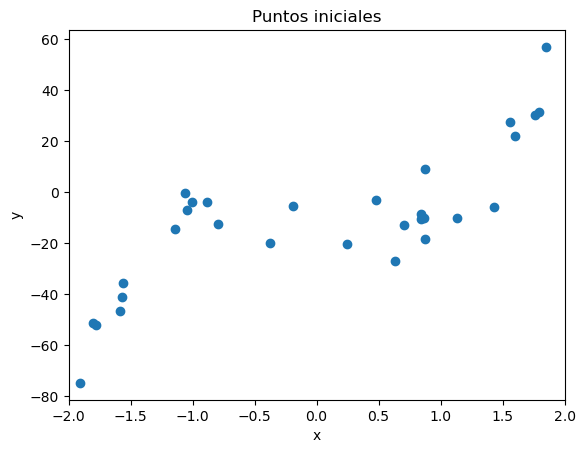

In [3]:
# generamos un conjunto de datos en el intervalo [-2,2]
a = -2.
b = 2.
n_points = 30
x_i = np.random.rand(n_points)*(b-a) + a

# generamos sus imagenes a partir de la función y(x) = 3*x^5 -2*x + ruido 
# El ruido lo genero normalmente distribuido entre 
y_x = 3*x_i**5 -2*x_i
max_val = max(abs(y_x))

ruido = np.random.normal(-(max_val)/10, max_val/10, n_points)
y_i = y_x + ruido

# Representamos los puntos iniciales
plt.scatter(x_i, y_i)
    
plt.title('Puntos iniciales')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(a, b)


### Dividimos el conjunto inicial en *Train/Test*

Tomamos 12 puntos como conjunto de datos de entrenamiento. 

(-2.0, 2.0)

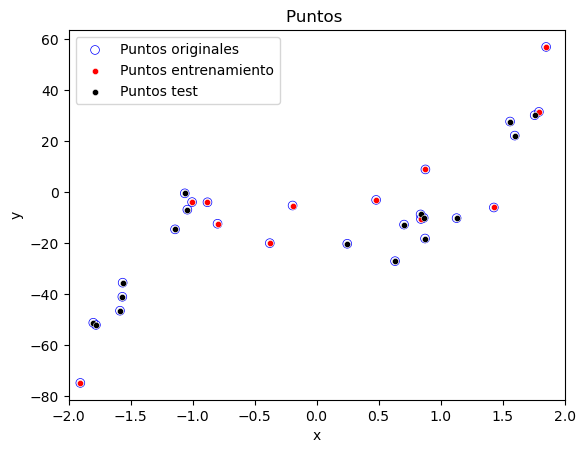

In [4]:
# Divido en training y test
n_train = 12
n_test = n_points-n_train
order = list(range(len(x_i)))
np.random.shuffle(order)

x_train = np.array([x_i[i] for i in order[0:n_train]])
y_train = np.array([y_i[i] for i in order[0:n_train]])

x_test = np.array([x_i[i] for i in order[n_train:]])
y_test = np.array([y_i[i] for i in order[n_train:]])


# Representamos los puntos iniciales
sns.scatterplot(x=x_i,y=y_i,  marker = 'o' , edgecolor='blue', facecolor='none', label= 'Puntos originales', s= 40 )
sns.scatterplot(x=x_train,y=y_train,  marker = 'o' , color = 'red', label= 'Puntos entrenamiento', s= 20 )
sns.scatterplot(x=x_test,y=y_test,  marker = 'o' , color = 'black', label= 'Puntos test', s= 20 )

plt.title('Puntos ')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(a, b)

### Regresion polinómica sobre los datos de test.

La manera en que vamos a calcular el polinomio de regresión de un determinado orden $p$ va a ser generar la matriz de datos sabiendo que sus columnas son potencias de orden creciente del vector con los datos originales:

$$
\boldsymbol{X} = \begin{pmatrix}
 x_1 & x_1^2 & \dots & x_1^p\\
 x_2 & x_2^2 & \dots & x_2^p\\
\vdots & \vdots & \dots & \vdots\\
 x_m & x_m^2 & \dots & x_m^p
\end{pmatrix}
$$

Esa matriz será el primer argumento de entrada en la función `normal_equation()` 
Vamos a calcular los coeficientes usando la **Ecuación Normal**. 



In [5]:
def normal_equation(X,y):
    """
    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    y: Vector columna con las imagenes de los datos de entrada conocidas. 

    Resuelvo la ecuación normal (X^T)X Theta = (X^T)Y
    Return Theta: vector de coeficientes de la regresión lineal
    """
    n_samples, n_features = X.shape

    # El primer paso será añadir la columna de 1's a los datos
    # Puedes usar la funcion de numpy np.column_stack((v,M)) que añade v como columna de M a la izquierda

    #***** TU CODIGO AQUI ********* (1 línea)
    X_1 = np.column_stack((np.ones(n_samples), X)) 
    #***** TU CODIGO AQUI *********

    # Construye la matriz (X^T)X y el vector (X^T)Y donde X es la matriz amplida con la columna de 1's

    #***** TU CODIGO AQUI ********* (2 líneas)
    A = X_1.T@X_1
    B = X_1.T@y
    #***** TU CODIGO AQUI *********

    # Resuelve el sistema lineal (X^T)X Theta = (X^T)Y usando la función adecuada de numpy

    #***** TU CODIGO AQUI ********* (1 línea)
    Theta =  np.linalg.solve(A,B)
    #***** TU CODIGO AQUI *********  
     
    return Theta

def predicted(X, Theta):
    """
    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    Theta: vector de coeficientes Theta que devuelve la ecuación normal

    Return Y = X Theta
    """
    n_samples, n_features = X.shape
    # El primer paso será añadir la columna de 1's a los datos
    # Puedes usar la funcion de numpy np.column_stack((v,M)) que añade v como columna de M a la izquierda

    #***** TU CODIGO AQUI ********* (1 línea)
    X_1 = np.column_stack((np.ones(n_samples), X)) 
    #***** TU CODIGO AQUI *********

    # Calcula el vector de predicciones asociado a los datos de entrada Y=X Theta siendo X es la matriz amplida con la columna de 1's
    
    #***** TU CODIGO AQUI ********* (1 línea)
    Y = X_1@Theta
    #***** TU CODIGO AQUI *********
  
    return  Y

Crea la matriz $\boldsymbol{X}$ de potencias sucesivas partiendo del conjunto de datos en $x$. Usaremos para esta primera prueba un polinomio de orden 5.

In [6]:
p = 5 # Orden polinómico

#***** TU CODIGO AQUI ********* 
X_train = np.array([[x**i for i in range(1,p+1) ] for x in x_train])
#***** TU CODIGO AQUI *********

*  Calculamos ahora los coeficientes del polinomio de regresión

In [7]:
#***** TU CODIGO AQUI ********* (1 línea)
Theta = normal_equation(X_train,y_train)
#***** TU CODIGO AQUI *********
print(Theta)

[ -8.24964806  23.98239894   5.10717919 -35.60572943  -0.96976631
  10.86199878]


### Dibujo el polinomio resultante.

Voy a definir funciones para poder pintar el polinomio y ver su comportamiento en el conjunto de datos de *Train*.

Vamos a implementar una función de nombre `polinomio` que dado un vector de coeficientes de tamaño $p+1$ y conjunto de puntos $\boldsymbol{x}$ devuelva el vector: 
$$
h_\Theta(\boldsymbol{x}) = \theta_0  + \theta_1 \boldsymbol{x} + \theta_2 \boldsymbol{x}^2 + \theta_3 \boldsymbol{x}^3 +  \dots +  \theta_p \boldsymbol{x}^p
$$

Text(0.5, 1.0, 'Polinomio aproximador')

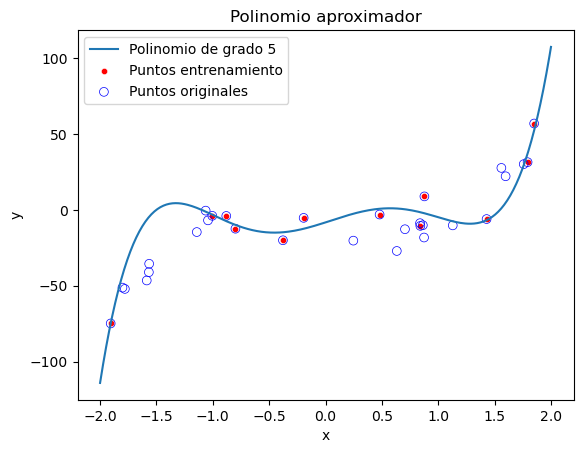

In [8]:
def polinomio(Theta, x):

    #***** TU CODIGO AQUI *********
    imagen = np.dot(Theta,np.array([x**i for i in range(len(Theta))]))
    
    #***** TU CODIGO AQUI *********

    return imagen

x_value = np.linspace(a,b,300)
y_value = polinomio(Theta,x_value)

# Representamos los puntos iniciales
sns.lineplot(x=x_value,y=y_value, label= 'Polinomio de grado ' +str(p) )
sns.scatterplot(x=x_train,y=y_train,  marker = 'o' , color = 'red', label= 'Puntos entrenamiento', s= 20 )
sns.scatterplot(x=x_i,y=y_i,  marker = 'o' , edgecolor='blue', facecolor='none', label= 'Puntos originales', s= 40 )
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polinomio aproximador')

### Representación del error cuadrático medio.

Estudia la evolución del error cuadrático según el grado del polinomio aproximador.
Vamos a distinguir entre el error que se comete en los puntos de *Train* y de *Test* para ver cuando el error se estabiliza en los puntos de *Train* (estamos intentando aproximar una función que es de grado 5) y tambien para ver como el error en los puntos de *Test* se dispara al aumentar el orden polinómico.

[[1, 330.0001530696633, 319.182761031724], [2, 324.6930277710607, 345.8265575642826], [3, 98.02209206625481, 67.43873347183862], [4, 97.55025752170339, 73.07515479366103], [5, 30.814573794231176, 394.374155521765], [6, 30.412292481459176, 283.4537303886729], [7, 25.07166690066458, 2117.8326469707745], [8, 21.682162341968503, 332.146999554888], [9, 13.39546793774386, 110808.06872118081], [10, 10.579527244607734, 646684.6234948959], [11, 9.70856783121719e-13, 10118090.73538265]]

Tabla de resultados:
       MSE en train   MSE en test
Orden                            
1      3.300002e+02  3.191828e+02
2      3.246930e+02  3.458266e+02
3      9.802209e+01  6.743873e+01
4      9.755026e+01  7.307515e+01
5      3.081457e+01  3.943742e+02
6      3.041229e+01  2.834537e+02
7      2.507167e+01  2.117833e+03
8      2.168216e+01  3.321470e+02
9      1.339547e+01  1.108081e+05
10     1.057953e+01  6.466846e+05
11     9.708568e-13  1.011809e+07


(-10.0, 1000.0)

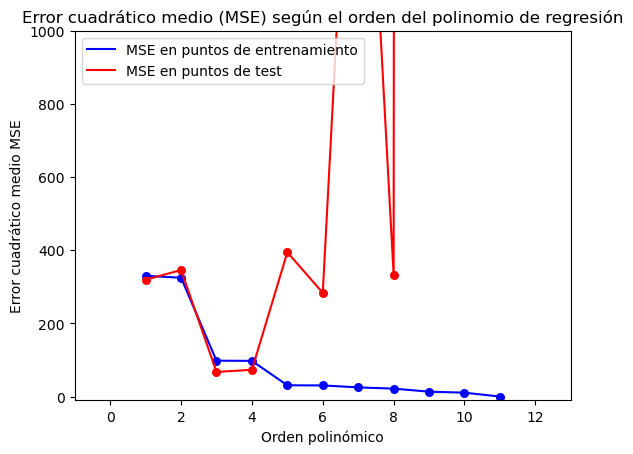

In [9]:
def MSE(y_true,y_predicted):
    error = 0.
    for i in range(len(y_true)):
        error += (y_true[i]-y_predicted[i])**2
    return error/len(y_true)
# Bucle para calcular el error sobre el conjunto de puntos de training 
# y de test dependiendo del orden polinómico empleado.
MSE_data = []
for orden in range(1,n_train):
    # Uso regresion polinómica para calcular el polinomio aproximador de orden 'orden'
    X_train = np.array([[x**i for i in range(1,orden+1) ] for x in x_train])
    coef = normal_equation(X_train,y_train)
    MSE_train = MSE(y_train,polinomio(coef,x_train))
    MSE_test  = MSE(y_test,polinomio(coef,x_test))
    MSE_data.append([orden, MSE_train, MSE_test])

print(MSE_data)

df_MSE = pd.DataFrame(MSE_data, columns=['Orden', 'MSE en train', 'MSE en test'])
df_MSE.set_index('Orden', inplace=True)
print("\nTabla de resultados:")
print(df_MSE)

# Representamos el error a medida que aumenta el orden polinomico
# Linea de Cerveza con marcadores
sns.lineplot(data=df_MSE['MSE en train'], color='blue', label='MSE en puntos de entrenamiento')
sns.lineplot(data=df_MSE['MSE en test'], color='red', label='MSE en puntos de test')
# Añadir marcadores
plt.scatter(df_MSE.index, df_MSE['MSE en train'], color='blue', s=30, marker='o')
plt.scatter(df_MSE.index, df_MSE['MSE en test'], color='red', s=30, marker='o')

plt.title('Error cuadrático medio (MSE) según el orden del polinomio de regresión')
plt.xlabel('Orden polinómico')
plt.ylabel('Error cuadrático medio MSE')
plt.legend(loc= 'upper left')
plt.xlim(-1, n_train + 1)
plt.ylim(-10, 1000)
    

### Representación gráfica de diferentes polinomios aproximadores.

Vamos a ver porqué ocurre que el error en *Train* se estabiliza mientras que el error en *Test* se dispara.
Representaremos 4 polinomios, los correspondientes a orden 1, 5, 8 y 11.
Una recta será insuficiente para aproximar correctamente los puntos generados con un polinomio de grado 5 (**Underfitting**).
El polinomio de grado 5 es el más adecuado para nuestro conjunto de datos mientras que los polinomios de grado 8 y, sobre todo, 11 sobreajustan su forma a los datos de *Train* mientras que cometen errores groseros sobre los puntos de *Test* (**Overfitting**).

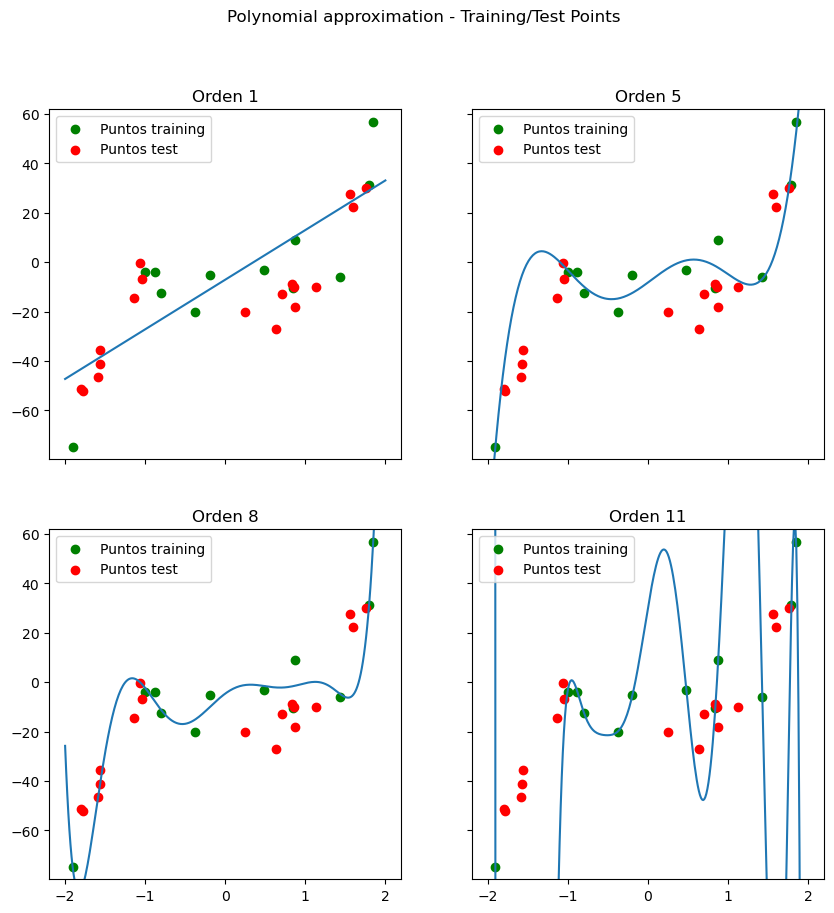

In [11]:
fig, axs = plt.subplots(2,2, figsize=(10, 10), sharex = True, sharey = True)
plt.xlim(a-0.2,b+0.2)
plt.ylim(min(y_i)-5, max(y_i)+5)
fig.suptitle('Polynomial approximation - Training/Test Points')

orden_list = [1,5,8,11]
for i,orden in enumerate(orden_list):
    X_train = np.array([[x**i for i in range(1,orden+1) ] for x in x_train])
    coef = normal_equation(X_train,y_train)
    y_train_predicted = polinomio(coef,x_train)
        
    # Generamos un conjunto de puntos de prueba 
    x_value = np.linspace(a,b,300)
    # Evalua la predicción para los puntos de prueba
    y_value =  polinomio(coef,x_value)
    
    ix = i//2
    iy = i%2

    axs[ix,iy].plot(x_value, y_value)
    axs[ix,iy].scatter(x_train,y_train, color= 'green', label= 'Puntos training')
    axs[ix,iy].scatter(x_test,y_test, color= 'red', label= 'Puntos test')
    axs[ix,iy].set_title('Orden '+str(orden))
    axs[ix,iy].legend(loc= 'upper left')    

    



